In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../tissue_dataset.csv")
X = df.drop(columns = ["target", "target_actual"])
y = df["target"]
lasso_features = pd.read_csv("../results/lasso_feature_ranking.csv")
rf_importances = pd.read_csv("../results/rf_importances_ranking.csv")
mi_importances = pd.read_csv("../results/mi_importances_ranking.csv")

In [ ]:
#XBG Model
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=122/11,
    random_state=42,
    n_jobs=-1
)
xgb.fit(X, y)

xgb_importances = pd.DataFrame({
    "miRNA": X.columns,
    "Importance": xgb.feature_importances_
})

xgb_importances = xgb_importances.sort_values(
    by="Importance",
    ascending=False
)

xgb_importances.reset_index(
    drop=True,
    inplace=True
)

xgb_importances.insert(
    0,
    "Rank",
    range(1, len(xgb_importances) + 1)
)
xgb_importances.head(20)
(xgb_importances["Importance"] > 0).sum()

np.int64(115)

In [9]:
#Save Ranking list
xgb_importances.to_csv(
    "../results/xgb_importances_ranking.csv",
    index=False
)

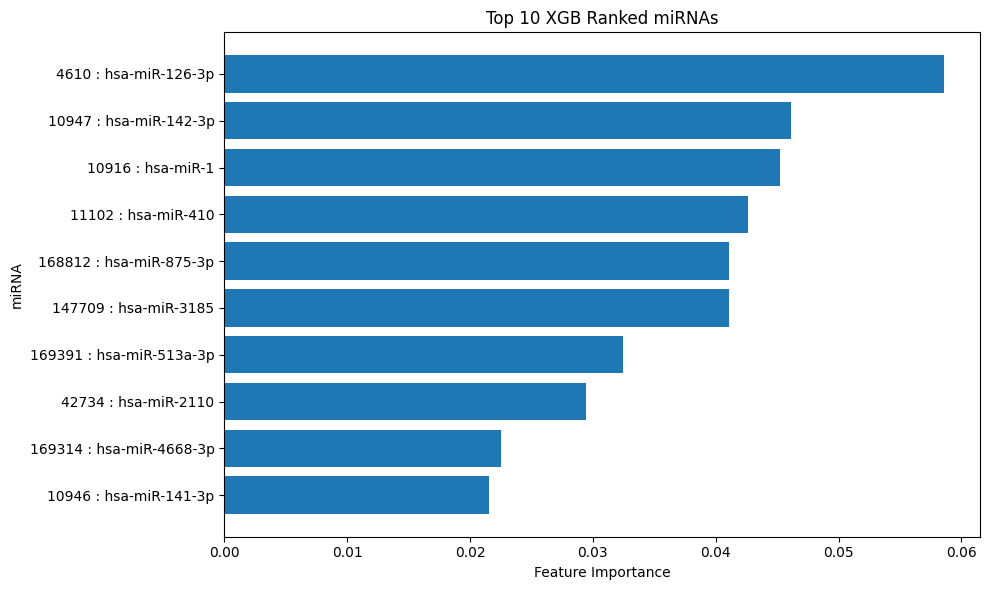

In [10]:
top10 = xgb_importances.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top10["miRNA"],
    top10["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("miRNA")
plt.title("Top 10 XGB Ranked miRNAs")

plt.gca().invert_yaxis()
plt.savefig(
    "../figures/XGB_top10",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

In [12]:
#Consensus Biomarker set 3
xgb_top20 = set(
    xgb_importances.head(20)["miRNA"]
)

lasso_set = set(
    lasso_features["miRNA"]
)

rf_top20 = set(
    rf_importances.head(20)["miRNA"]
)

mi_top20 = set(
    mi_importances.head(20)["miRNA"]
)
lasso_set.intersection(
    rf_top20,
    mi_top20,
    xgb_top20
)

{'147709 : hsa-miR-3185', '168791 : hsa-miR-4785'}